In [1]:
import numpy as np
import matplotlib.pyplot as plt

/home/deve/myenv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
#function
def thomas_solve(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

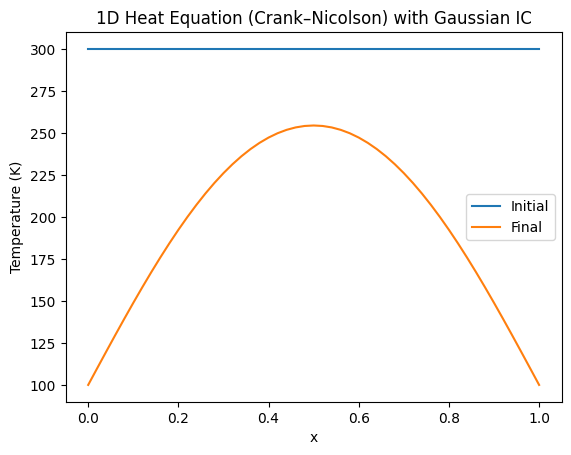

In [3]:
#Q1 -> After some finite time t
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 100.0
T_right= 100.0

# Uniform initial condition
T = np.full(Nx, 300.0)

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
plt.plot(x, time_history[0], label='Initial')
plt.plot(x, T, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()

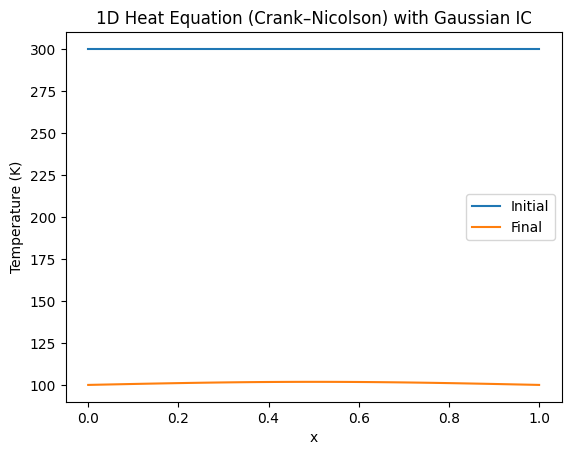

In [4]:
#Q1 -> After infinite time t
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 50000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 100.0
T_right= 100.0

# Uniform initial condition
T = np.full(Nx, 300.0)

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
plt.plot(x, time_history[0], label='Initial')
plt.plot(x, T, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()

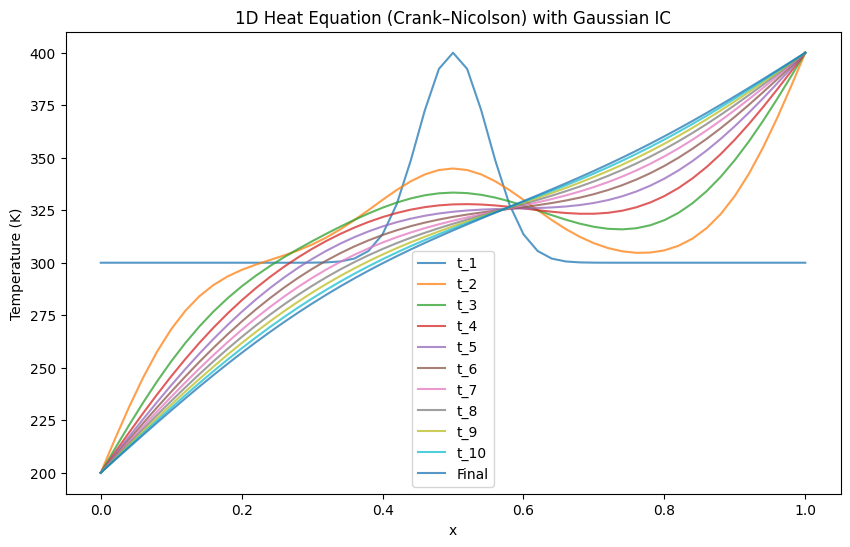

In [5]:
#Q2 -> several temperature profiles at different time steps
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 200.0
T_right= 400.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
for i in range(Nx):
    T[i] += 100*np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
fig, ax = plt.subplots(figsize = (10,6))
j = 1
for i in range(0,5000,500):
    ax.plot(x, time_history[i], label=f't_{j}', alpha = 0.75)
    j+=1
ax.plot(x, time_history[-1],alpha = 0.75, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()

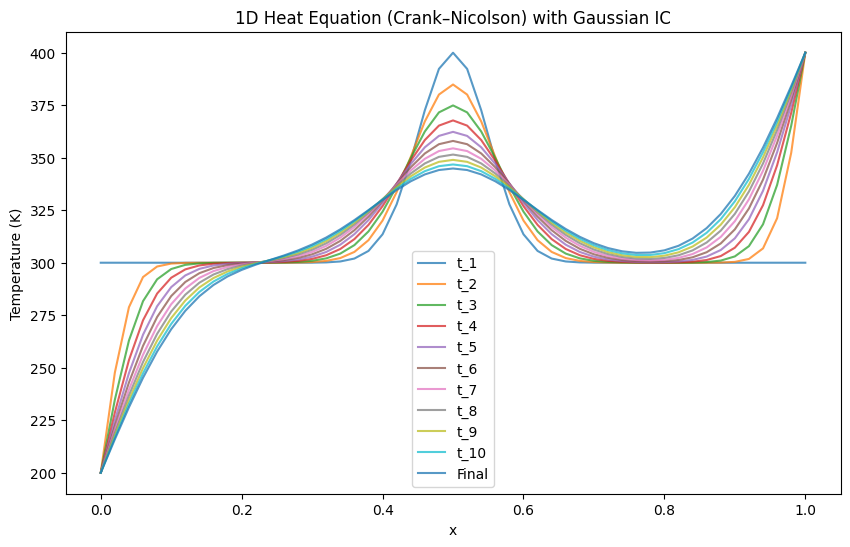

In [6]:
#Q2 -> several temperature profiles at different time steps with smaller alpha
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-5
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 200.0
T_right= 400.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
for i in range(Nx):
    T[i] += 100*np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
fig, ax = plt.subplots(figsize = (10,6))
j = 1
for i in range(0,5000,500):
    ax.plot(x, time_history[i], label=f't_{j}', alpha = 0.75)
    j+=1
ax.plot(x, time_history[-1],alpha = 0.75, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()

#We can see that smaller alpha implies more time to diffuse, and reduces the convergence speed

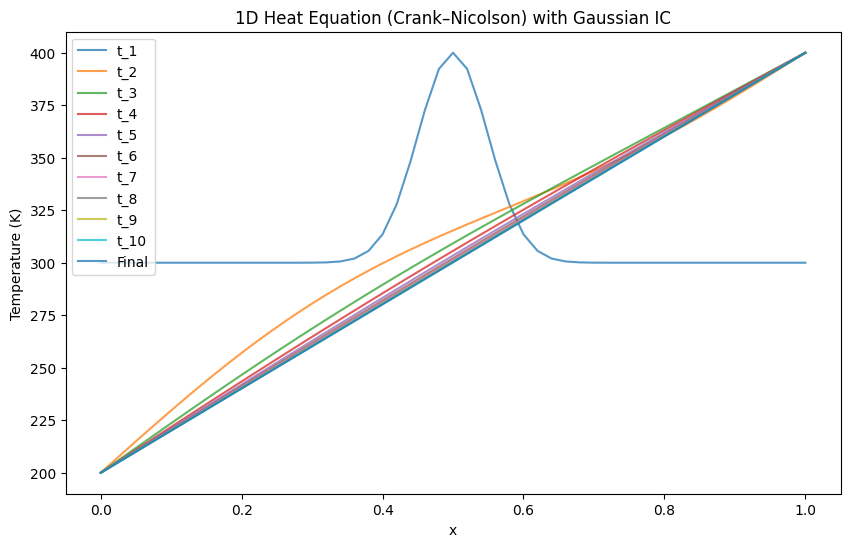

In [7]:
#Q2 -> several temperature profiles at different time steps with larger alpha
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-3
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 200.0
T_right= 400.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
for i in range(Nx):
    T[i] += 100*np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot final vs initial
fig, ax = plt.subplots(figsize = (10,6))
j = 1
for i in range(0,5000,500):
    ax.plot(x, time_history[i], label=f't_{j}', alpha = 0.75)
    j+=1
ax.plot(x, time_history[-1],alpha = 0.75, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()

#We can see that larger alpha implies less time to diffuse, and increases the convergence speed